# K-means - unsupervised algorithm

- Groups unlabel data into clusters

# 4 steps process
1) Initialize -  choose number of k clusters
2) Assign - measure the distance of each datapoint with nearest centroid
3) Update  - recalculate the center (avg) of all data points assigned to specific cluster. Move centroid to new mean
4) Repeate - continue 2 & 3 until centroids stop to move

- No train test split on kmeans

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('marketing_campaign_response.csv')
df


,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded
0,22,27.8,5,18,73,1,1
1,36,23.2,4,10,298,1,1
2,31,21.1,4,8,225,1,0
3,39,21.4,0,29,235,0,0
4,26,26.5,4,15,76,1,0
...,...,...,...,...,...,...,...
495,47,4.7,5,0,89,1,1
496,58,10.3,2,20,186,1,1
497,39,15.7,1,8,12,1,0
498,30,8.9,5,19,106,0,1


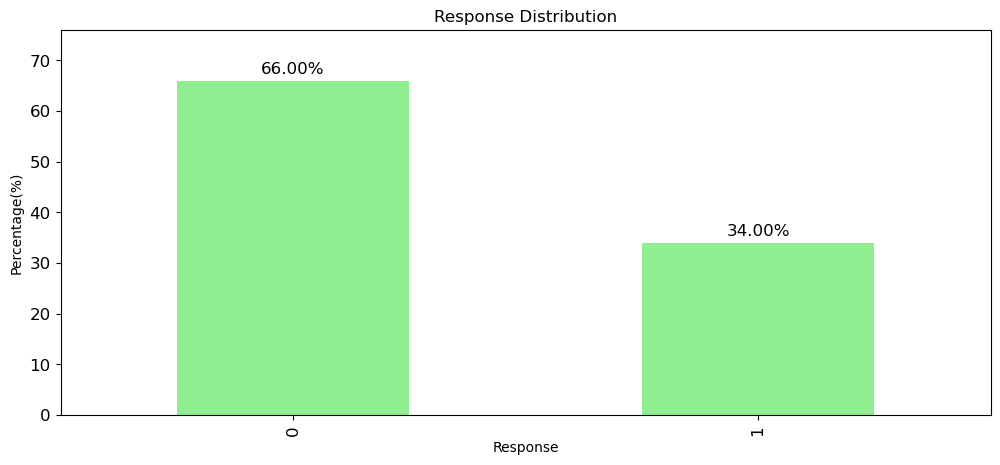

In [3]:
# Target value distribution of people who responded vs not responded


Responded_distribution = df['Responded'].value_counts(normalize=True)*100

ax = Responded_distribution.plot(kind='bar', figsize=(12,5), fontsize=12, color='lightgreen')

# % sign on top of bar
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=12)

# padding so the labels don't get cut off at the top
ax.set_ylim(0, Responded_distribution.max() + 10)

ax.set_xlabel("Response")
ax.set_ylabel("Percentage(%)")
ax.set_title("Response Distribution")
plt.show()


# Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Responded')

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X) # Scaler directly on X(whole training data)

print("X Train scaled", X_scaled.shape)

X Train scaled (500, 6)


In [5]:
X_scaled # all the rows are Scaled!

array([[-1.27898295e+00,  1.61582022e+00,  1.26693878e+00,
         3.40699193e-01, -9.62940191e-01,  1.00400803e+00],
       [-2.70889193e-01,  1.01088053e+00,  6.51322267e-01,
        -5.75774762e-01,  1.16073454e+00,  1.00400803e+00],
       [-6.30922677e-01,  7.34712408e-01,  6.51322267e-01,
        -8.04893251e-01,  4.71720069e-01,  1.00400803e+00],
       ...,
       [-5.48691029e-02,  2.45658119e-02, -1.19552726e+00,
        -8.04893251e-01, -1.53869201e+00,  1.00400803e+00],
       [-7.02929374e-01, -8.69692865e-01,  1.26693878e+00,
         4.55258437e-01, -6.51467897e-01, -9.96007968e-01],
       [-7.02929374e-01, -2.12149720e-01,  1.26693878e+00,
        -1.72136721e+00, -2.07648195e-04, -9.96007968e-01]])

In [6]:
# Build K-means where k=3, 3 centroids(clusters)

from sklearn.cluster import KMeans
model = KMeans(n_clusters=3, random_state=42)
model.fit(X_scaled)     # no y, just X

df['Cluster'] = model.labels_  # adds group number to "each customer"

In [10]:
# So there are 3 cluster 0,1,2 -- each customer is assingned to each cluster
df

# have to find what kind of people are in each cluster?

,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded,Cluster
0,22,27.8,5,18,73,1,1,1
1,36,23.2,4,10,298,1,1,1
2,31,21.1,4,8,225,1,0,1
3,39,21.4,0,29,235,0,0,0
4,26,26.5,4,15,76,1,0,1
...,...,...,...,...,...,...,...,...
495,47,4.7,5,0,89,1,1,1
496,58,10.3,2,20,186,1,1,1
497,39,15.7,1,8,12,1,0,1
498,30,8.9,5,19,106,0,1,0


In [11]:
df.groupby('Cluster').mean().round(2)

,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded
Cluster,,,,,,,
0,32.97,15.30,2.82,23.07,185.16,0.0,0.40
1,39.51,15.06,2.84,14.94,172.42,1.0,0.41
2,45.32,16.47,3.22,9.10,171.90,0.0,0.17


In [ ]:
# Email engagement is strong in Cluster 0
# Even though cluster 1 has mobile app, that dosen't mean they are active
# Purchasing power is close to similar for all 3 clusters

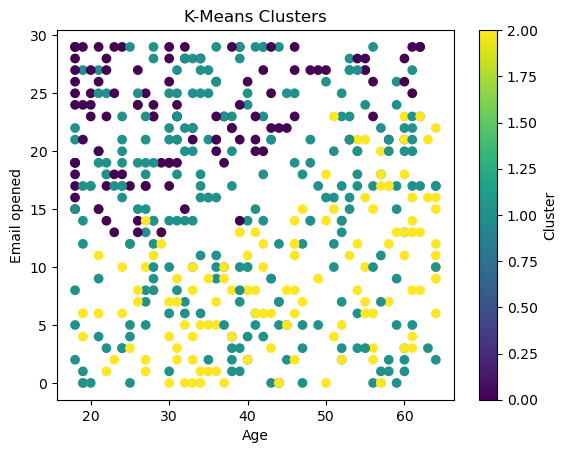

In [16]:
plt.scatter(df['Age'], df['Email_Opens_90Days'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Email opened')
plt.title('K-Means Clusters')
plt.colorbar(label='Cluster')
plt.show()

# Cluster 0 - purple - most young people open mails alot of time 
# cluster 1 - pale ygreen - this people are spred across the data 
# cluster 2 - pale yellow - the old group dose not opens the email more often

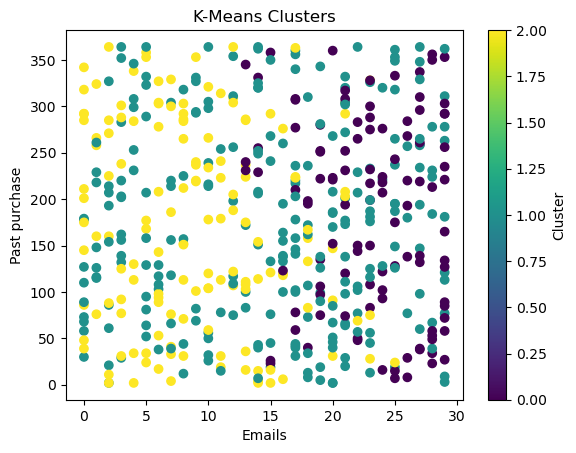

In [ ]:
plt.scatter(df['Email_Opens_90Days'], df['Days_Since_Last_Purchase'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Emails')
plt.ylabel('Past purchase')
plt.title('K-Means Clusters')
plt.colorbar(label='Cluster')
plt.show()

# Hypothetically when compared with the above columns.
# We see the Cluster 0- purple - tends to open more emails, and has less past purchase date
# In cluster 1 - (pale green)People are spread across, they most of the opn, most of them dont
# In cluster 2 - (pale yellow) - the old group are more towards opening less emails and has not purchased from many days

In [14]:
df['Cluster'].value_counts().sort_values(ascending=False)

Cluster
1    249
2    143
0    108
Name: count, dtype: int64